# Modeling Approaches and Considerations

Now that we've gone through the extensive process of finding, exploring, annotating, and curating our datasets - we're ready to start the modeling process.

In this notebook, we're going to go through three main approaches:
1. Rule-based approach
2. Machine learning approach
3. GenAI: RAG Approach

<br/>

In each case, we will levereage the best practices discussed in the book, including:
- Consistent training and testing sets
- Testing performance multiple ways (e.g. sentence vs document level)
- Out of sample testing to demonstrate generalizability

<br/>

First, let's load packages and the data we need from previous notbooks:

In [2]:
import pandas as pd
import numpy as np
import os
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import ks_2samp
import umap.umap_ as umap
import matplotlib as mpl
import matplotlib.pyplot as plt
import openai
from openai import OpenAI
import annoy
from annoy import AnnoyIndex
import math
import random
import pickle
import json
from dotenv import load_dotenv

In [ ]:
load_dotenv()
HOME_DIRECTORY = r'D:\Usersss\end-to-end-ML-Pipeline'

sent_emb_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

In [4]:
## Load Payment terms annotations
payment_annos_all = pd.read_excel(os.path.join(HOME_DIRECTORY, 'data', 'annotations', 'Payment_semantic_search-annotated.xlsx'), engine='openpyxl')

### Convert to embeddings
payment_annos_all['Embedding'] = payment_annos_all['Text'].apply(lambda t: sent_emb_model.encode(t))

### Remove false positives
payment_annos = payment_annos_all[payment_annos_all['Answer']!='FALSE POSITIVE']

### Check
payment_annos[['Filename', 'Text', 'Answer']].head()

,Filename,Text,Answer
0,tm2421105d1_ex10-1.htm,Payment of invoices submitted for Services wil...,30
1,tm2022502d7_ex10-1.htm,Except as the applicable Provider and Recipien...,30
2,d203747dex1015.html,6.3 Unless otherwise agreed in writing by\nthe...,30
3,pinstripesdistributionag.html,The Customer agrees to pay such invoices withi...,30
4,spar ex99-1.htm,● All\n ...,30


In [6]:
#sentence_embeddings = pd.read_pickle(os.path.join(HOME_DIRECTORY, 'data', 'data_pickles', 'corpus_sentences_embedded.pkl'))
#sentence_embeddings.reset_index(inplace=True)
#sentence_embeddings.drop('index', axis=1, inplace=True)

#sentence_embeddings['Label'] = 0*len(sentence_embeddings)

#sentence_embeddings['Label'].loc[(sentence_embeddings['filename'].isin(payment_annos['Filename'])) & (
 #       sentence_embeddings.index.isin(payment_annos['Index']))] = 1

In [5]:
sentence_embeddings = pd.read_pickle(os.path.join(HOME_DIRECTORY, 'data', 'data_pickles', 'corpus_sentences_embedded.pkl'))
sentence_embeddings.reset_index(inplace=True)
sentence_embeddings.drop('index', axis=1, inplace=True)

sentence_embeddings['Label'] = 0 * len(sentence_embeddings)

condition = (sentence_embeddings['filename'].isin(payment_annos['Filename'])) & (sentence_embeddings.index.isin(payment_annos['Index']))
sentence_embeddings.loc[condition, 'Label'] = 1

<br/>

Let's sanity check to make sure our labels are set up correctly -- first the positives:

In [6]:
sentence_embeddings[sentence_embeddings.index.isin(payment_annos['Index'])].head()

,filename,sentence_index,sentence_text,Embedding,Label
498,{BEAB7EBB-320F-40B6-A8EC-46FA106E041A}.pdf.txt,381,The City will process\npayment within 60 days ...,"[-0.16759498, -0.27937645, 0.01358771, -0.3186...",1
5046,{37D87A51-8A39-4C71-A95E-39039D4F8035}.pdf.txt,2685,Payment willbe processed within 60 days ater t...,"[0.038814455, -0.17314807, -0.3497632, -0.2625...",1
6454,00000JZM.pdf.txt,308,The City wil\nprocess the payment within 60 ca...,"[0.25620103, 0.11852089, -0.233818, -0.2146448...",1
20328,000023CH.pdf.txt,273,The City will process payment within 60 days a...,"[-0.047622316, -0.079943694, 0.051177025, -0.2...",1
31327,00001Q81.pdf.txt,1059,The Depariment wil process propery completed i...,"[-0.1272221, -0.02062763, -0.11731366, -0.2323...",1


<br/>

Let's double check the negatives:

In [7]:
sentence_embeddings[~sentence_embeddings.index.isin(payment_annos['Index'])].head()

,filename,sentence_index,sentence_text,Embedding,Label
0,00002MGK.pdf.txt,0,Modification Summary Report\n\n,"[-0.41111374, 0.21261811, 0.20041092, -0.20724...",0
1,00002MGK.pdf.txt,1,Conteact (PO) Number: 1406\nModification Revis...,"[-0.5395347, 0.098074794, 0.105878145, -0.1364...",0
2,00002MGK.pdf.txt,2,Specification Number: 3858\n\n,"[-1.0228841, 0.4157112, -0.75348186, -0.048902...",0
3,00002MGK.pdf.txt,3,Name of Contractor: GLOBETROTTERS ENGINEERING ...,"[-0.38846922, -0.24451904, -0.4939656, -0.3636...",0
4,00002MGK.pdf.txt,4,City Department: DEPARTMENT OF CONSTRUCTION AN...,"[0.008176829, -0.01078279, -0.06635815, -0.172...",0


<br/><br/><br/>

# 0. Define Train and Test Sets

Regardless of what approach we are using for modeling, we need to have a consistent training set and testing set. This will enable us to compare apples to apples across the board.

In [8]:
random.seed(12345)
test_files = random.sample(list(payment_annos['Filename'].values), 
                          round(0.2*len(payment_annos)))
train_files = [i for i in payment_annos['Filename'].values if i not in test_files]

<br/>

Sanity check to confirm everything adds up:
1. total length of annotations == test + train lengths
2. no intersection / overlap between train and test

In [9]:
len(test_files), len(train_files), len(test_files)+len(train_files)==len(payment_annos)

(58, 234, True)

<br/>

Now let's add flags to our annotation dataframe for which positive annotations are in the test set vs the train set - we will add another column to track this information as we use it throughout our different modeling approaches:

In [10]:
#payment_annos['Dataset'] = ['Test' if ann in test_files else 'Train' for ann in payment_annos['Filename'].values]
#payment_annos.head()

In [11]:
payment_annos = payment_annos.copy()

payment_annos['Dataset'] = ['Test' if ann in test_files else 'Train' for ann in payment_annos['Filename'].values]
payment_annos.head()

,Filename,Index,Cosine Similarity,Text,Embedding,Answer,Comment,Dataset
0,tm2421105d1_ex10-1.htm,796139,0.826294,Payment of invoices submitted for Services wil...,"[-0.116843596, -0.26367626, -0.0731017, -0.445...",30,NaN,Train
1,tm2022502d7_ex10-1.htm,817242,0.813836,Except as the applicable Provider and Recipien...,"[-0.05047694, 0.053603776, -0.19440988, -0.068...",30,NaN,Test
2,d203747dex1015.html,902124,0.801718,6.3 Unless otherwise agreed in writing by\nthe...,"[0.1087767, 0.025595166, -0.09234306, -0.09299...",30,NaN,Train
3,pinstripesdistributionag.html,856859,0.799900,The Customer agrees to pay such invoices withi...,"[-0.06774465, -0.0757823, -0.23485002, -0.3507...",30,NaN,Test
4,spar ex99-1.htm,876506,0.797764,● All\n ...,"[-0.17738378, -0.06491182, 0.04999843, -0.2361...",30,NaN,Train


<br/>

Now let's do a double check of our train/test split:

In [12]:
payment_annos['Dataset'].value_counts()

Dataset
Train    234
Test      58
Name: count, dtype: int64

<br/><br/>

We also need to apply this to our general population so that we can also test the negative examples as well as the positive ones:

In [13]:
sentence_embeddings['Dataset'] = ['Train']*len(sentence_embeddings)
test_inds = sentence_embeddings.sample(frac=0.2, random_state=12345).index
sentence_embeddings.loc[test_inds, 'Dataset'] = 'Test'

And let's do another sanity check to confirm our split:

In [14]:
sentence_embeddings['Dataset'].value_counts()

Dataset
Train    774359
Test     193590
Name: count, dtype: int64

<br/><br/><br/>

# 1. Rule-Driven Approach

With a rule-driven, deterministic approach, we typically create a handful of business rules to capture the common patterns we see in the language of our annations. However, we very quickly need to balance this by checking how many false positives we will get from these same rules across the other sentences in the corpus.

Most who are familiar with leveraging regular expressions to find and extract information out of a corpus know that it is almost an art form to create a rule that is precise enough to find the language that we are looking for, without being overly surgical in a way that makes it too brittle and prone to fail when new language is run through the regular expressions.

First, let's write a couple quick rules -- which we can write quickly based on our experience with the annotations. The best practice is to use a train set (for rule development and iteration) and test set (for rule test) split to develop the regex. In this case, we will develop with a train-test split on our annotations, and additionally test on an out of sample set.

In [15]:
def rule_search(text):
    if re.search('(payment[\w\W]{,30}days|days[\w\W]{,30}payment)', text, re.IGNORECASE):
        return True
    elif re.search('(pay\s[\w\W]{,30}\d\d[\w\W]{,10}day|\d\d[\w\W]{,10}day[\w\W]{,30}pay\s)', text, re.IGNORECASE):
        return True
    elif re.search('((pay|paid)\s[\w\W]{,150}\d\d[\w\W]{,10}day|\d\d[\w\W]{,10}invoice)', text, re.IGNORECASE):
        return True
    else:
        return False

<br/>
We can quickly run this over our annotations and see that it's fairly effective on our train set:

In [16]:
def assess_rules(payment_annos, dataset):
    print('Percent Annotations Captured by rules:', 
      round(sum(payment_annos[payment_annos['Dataset']==dataset]['Text'].apply(
          lambda x: rule_search(x)))/len(payment_annos[payment_annos['Dataset']==dataset])*100,2))
    return payment_annos[payment_annos['Dataset']==dataset]['Text'].apply(lambda x: rule_search(x))

In [17]:
assess_rules(payment_annos, 'Train')

Percent Annotations Captured by rules: 63.68


0      False
2       True
4       True
6      False
7       True
       ...  
338     True
339     True
342     True
345    False
347    False
Name: Text, Length: 234, dtype: bool

<br/>

Great news - it took all of 3 minutes and we now have a rule that captures about 65% of our annotations correctly. For some use cases, that might be entirely sufficient, and if so, then this is the approach for us.

<br/>

### Exercise 6.1:

Update and add regex rules to improve precision and recall on the training set.

<br/>

In [18]:
def rule_search(text):
    if re.search(r'(payment[\w\W]{,30}days|days[\w\W]{,30}payment)', text, re.IGNORECASE):
        return True
    elif re.search(r'(pay\s[\w\W]{,30}\d\d[\w\W]{,10}day|\d\d[\w\W]{,10}day[\w\W]{,30}pay\s)', text, re.IGNORECASE):
        return True
    elif re.search(r'((pay|paid)\s[\w\W]{,150}\d\d[\w\W]{,10}day|\d\d[\w\W]{,10}invoice)', text, re.IGNORECASE):
        return True

    elif re.search(r'\bnet[- ]?(10|15|30|45|60|90)\b', text, re.IGNORECASE):
        return True
        
    elif re.search(r'(due|payable)[\w\W]{,20}within[\w\W]{,20}\d{2}[\w\W]{,10}day', text, re.IGNORECASE):
        return True

    elif re.search(r'\d{2}[\w\W]{,10}day[\w\W]{,30}receipt[\w\W]{,20}invoice', text, re.IGNORECASE):
        return True
        
    else:
        return False

<br/>

Once we've done some iterations and are satisfied with the train performance, we can assess against our test set:

In [19]:
assess_rules(payment_annos, 'Test')

Percent Annotations Captured by rules: 84.48


1      False
3       True
5       True
12     False
13     False
20      True
21      True
39      True
46      True
50      True
54      True
61     False
63      True
66      True
75      True
84      True
85      True
88      True
92      True
94      True
96      True
98      True
100     True
102     True
110     True
115     True
123     True
124    False
138     True
140     True
146     True
156     True
162     True
175     True
179     True
184     True
185     True
193     True
200    False
203    False
204     True
232     True
233    False
234    False
246     True
248     True
250     True
262     True
293     True
298     True
301     True
305     True
308     True
312     True
334     True
337     True
340     True
343     True
Name: Text, dtype: bool

<br/>

But, before we celebrate too much, let's see how many false positives we get across the same annotated documents:

In [20]:
sentence_embeddings['Rule_Results'] = sentence_embeddings['sentence_text'].apply(lambda x: rule_search(x))

<br/>

Below, we count up how many "True" predictions that our rule captures and calculate some of our usual, basic metrics. To do this, we're going to look at the documents we annotated, and see how many sentences in those documents trigger our regular expression rules, and out of those sentences, which were annotated (true positives) and which were not (false positives).

Then we can calculate our usual metrics from there...

In [21]:
def get_fn_tps(dataset, payment_annos):
    rule_results = {
        'True Positives': sum(dataset[(dataset['filename'].isin(payment_annos['Filename'])) & (dataset.index.isin(payment_annos['Index']))]['Rule_Results']),
        'False Negatives': len(dataset[(dataset['filename'].isin(payment_annos['Filename'])) & (dataset.index.isin(payment_annos['Index']))]['Rule_Results'])-sum(dataset[(dataset.index.isin(payment_annos['Index']))]['Rule_Results']),
        'True Negatives': len(dataset[(dataset['filename'].isin(payment_annos['Filename'])) & ~dataset.index.isin(payment_annos['Index'])]['Rule_Results'])- sum(dataset[~dataset.index.isin(payment_annos['Index'])]['Rule_Results']),
        'False Positives': sum(dataset[(dataset['filename'].isin(payment_annos['Filename'])) & ~dataset.index.isin(payment_annos['Index'])]['Rule_Results'])}

    return rule_results

def calculate_metrics(dataset, payment_annos):
    res_dict = get_fn_tps(dataset, payment_annos)
    metrics = {
        'Accuracy': round((res_dict['True Positives']+res_dict['True Negatives'])/(res_dict['True Positives']+res_dict['True Negatives']+res_dict['False Positives']+res_dict['False Negatives']), 4),
        'Precision': round(res_dict['True Positives']/(res_dict['True Positives']+res_dict['False Positives']), 4),
        'Recall': round(res_dict['True Positives']/(res_dict['True Positives']+res_dict['False Negatives']), 4),
    }
    return res_dict, metrics

In [22]:
calculate_metrics(sentence_embeddings[sentence_embeddings['Dataset']=='Train'], payment_annos)

({'True Positives': 178,
  'False Negatives': 58,
  'True Negatives': 217039,
  'False Positives': 316},
 {'Accuracy': 0.9983, 'Precision': 0.3603, 'Recall': 0.7542})

In [23]:
calculate_metrics(sentence_embeddings[sentence_embeddings['Dataset']=='Test'], payment_annos)

({'True Positives': 48,
  'False Negatives': 8,
  'True Negatives': 54291,
  'False Positives': 88},
 {'Accuracy': 0.9982, 'Precision': 0.3529, 'Recall': 0.8571})

<br/>

... and as we can see, although we are capturing most of our true examples, we are unfortunately going to have quite a large number of false positives compared to our true positives. And, this is only the first step of finding and extracting the right context, and doesn't even include the interpretation and standardization step.

<br/>

### Exercise 6.2:

The metrics are currently being calculated at the sentence level. Write code to calculate the performance metrics of this approach at the *document* level, and apply to both the training and testing sets.

Consider these questions as you build the code for document level performance metrics:
- Will you consider a document correct if the regex picks up the true positive as well as additional false positives (e.g. is it correct if 1 of 3 are correct)?
- Will you pick the first hit in the document and see if it is correct?
- Will you build additional custom heuristics in ordering your regex rules in order of specificity?

Working with rules can be highly effective when there is consistent data - but can be a challenge to scale and manage effectively.

*Note that per best practices, we would typically look at both the sentence and document level training metrics as we iterate during development. Then, when ready, we would look at the sentence and document level metrics for the test set. The order is adjusted here for the sake of exercises.*

<br/>

In [24]:
def calculate_document_metrics(df, payment_annos):
    true_payment_docs = set(payment_annos['Filename'].unique())

    flagged_docs = set(df[df['Rule_Results'] == True]['filename'].unique())
    
    all_docs = set(df['filename'].unique())
    
    tp_docs = flagged_docs.intersection(true_payment_docs) 
    fp_docs = flagged_docs - true_payment_docs         
    fn_docs = true_payment_docs - flagged_docs          
    tn_docs = (all_docs - true_payment_docs) - flagged_docs 
    
    precision = len(tp_docs) / len(flagged_docs) if len(flagged_docs) > 0 else 0
    recall = len(tp_docs) / len(true_payment_docs) if len(true_payment_docs) > 0 else 0
    accuracy = (len(tp_docs) + len(tn_docs)) / len(all_docs)
    
    return {
        'Counts': {'TP': len(tp_docs), 'FP': len(fp_docs), 'FN': len(fn_docs), 'TN': len(tn_docs)},
        'Metrics': {'Accuracy': round(accuracy, 4), 'Precision': round(precision, 4), 'Recall': round(recall, 4)}
    }

print("--- Document Level: TRAIN SET ---")
print(calculate_document_metrics(sentence_embeddings[sentence_embeddings['Dataset']=='Train'], payment_annos))

print("\n--- Document Level: TEST SET ---")
print(calculate_document_metrics(sentence_embeddings[sentence_embeddings['Dataset']=='Test'], payment_annos))

--- Document Level: TRAIN SET ---
{'Counts': {'TP': 234, 'FP': 387, 'FN': 58, 'TN': 1161}, 'Metrics': {'Accuracy': 0.7582, 'Precision': 0.3768, 'Recall': 0.8014}}

--- Document Level: TEST SET ---
{'Counts': {'TP': 103, 'FP': 148, 'FN': 189, 'TN': 1397}, 'Metrics': {'Accuracy': 0.8165, 'Precision': 0.4104, 'Recall': 0.3527}}


### Methodology
To assess the practical utility of the heuristic approach, a document-level evaluation framework was implemented. Unlike sentence-level metrics, which evaluate individual strings, the document-level view considers a classification successful if the ruleset identifies at least one true payment term within a specific file.

The logic employed utilizes a "Found-Any" threshold: if a document is flagged by the regex and contains at least one ground-truth annotation, it is categorized as a True Positive (TP). If a document with no ground truth is flagged, it is a False Positive (FP).

In [25]:
OOS_annos = pd.read_excel(os.path.join(HOME_DIRECTORY, 'data', 'annotations', 'Payment_OOS_CUAD-annotated.xlsx'), engine='openpyxl')
OOS_annos.head()

,Filename,Index,Cosine Similarity,Text,Embedding,Answer
0,MERCATAINC_03_09_2000-EX-10.21-SPONSORSHIP AGR...,75171,0.818270,Invoices are payable thirty (30) days ...,[ 2.73382105e-02 2.43578479e-01 1.58090532e-...,30
1,LiquidmetalTechnologiesInc_20200205_8-K_EX-10....,125364,0.794762,Payment terms are net 30 days after the date o...,[ 5.75190336e-02 1.15242578e-01 1.55434303e-...,30
2,HEALTHGATEDATACORP_11_24_1999-EX-10.1-HOSTING ...,29071,0.781155,Invoices are payable within 60 days of receipt...,[-3.42358910e-02 2.09649265e-01 1.19534194e-...,60
3,BNCMORTGAGEINC_05_17_1999-EX-10.4-LICENSING AN...,9927,0.777679,Invoices will be paid within 15 days of receipt.,[ 1.30046410e-02 2.48915225e-01 1.91053916e-...,15
4,FuseMedicalInc_20190321_10-K_EX-10.43_11575454...,17614,0.775361,5.3 The Distributor must pay the full amount i...,[ 2.23518938e-01 -2.30259091e-01 -4.44820106e-...,45


<br/>

As an exercise, the user can create the embedded pickle for the out-of-sample CUAD data. The pickle loaded below is also available via the Google Drive.

In [26]:
#OOS_sentences = pd.read_pickle(os.path.join(HOME_DIRECTORY, 'data', 'data_pickles', 'OOS_CUAD_sentences_embedded.pkl'))
#OOS_sentences['Label'] = 0*len(OOS_sentences)
#OOS_sentences['Label'].loc[(OOS_sentences['filename'].isin(OOS_annos['Filename'])) & (
 #       OOS_sentences.index.isin(OOS_annos['Index']))] = 1
#OOS_sentences.head()

In [27]:
OOS_sentences = pd.read_pickle(os.path.join(HOME_DIRECTORY, 'data', 'data_pickles', 'OOS_CUAD_sentences_embedded.pkl'))

OOS_sentences['Label'] = 0

condition = (OOS_sentences['filename'].isin(OOS_annos['Filename'])) & (OOS_sentences.index.isin(OOS_annos['Index']))
OOS_sentences.loc[condition, 'Label'] = 1

OOS_sentences.head()

,filename,sentence_index,sentence_text,Embedding,Label
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,0,EXHIBIT 10.6\n\n ...,"[-0.10622965, -0.44307116, -0.17057964, 0.1905...",0
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,1,\n\n RECITA...,"[0.026612738, -0.21556377, -0.27186835, -0.283...",0
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,2,The Company is presently engaged in the bus...,"[-0.4307863, -0.012101413, -0.10511014, 0.2095...",0
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,3,The Company may engage in the business of sel...,"[-0.12590498, -0.45511994, -0.26844802, -0.373...",0
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,4,\n\n B. Representations.,"[-0.23541977, 0.1468132, -0.5211692, 0.0794706...",0


<br/><br/>

Let's do a quick comparison of our original dataset compared to our CUAD out of sample dataset - we'll compare the overall corpus distribution by visualizing the embeddings in the same space.

In [28]:
def plot_comparison_corpora(sentence_embeddings1, sentence_embeddings2, embedding_col, sample_size=None):
    if sample_size is None:
        sentence_embeddings_sample1 = sentence_embeddings1
        sentence_embeddings_sample2 = sentence_embeddings2
    else:
        sentence_embeddings_sample1 = sentence_embeddings1.sample(sample_size, random_state=100)
        sentence_embeddings_sample2 = sentence_embeddings2.sample(sample_size, random_state=100)

    reducer = umap.UMAP(n_neighbors=20, random_state=1)
    umap_embeds = reducer.fit_transform(np.array([np.array(x) for x in pd.concat((
        sentence_embeddings_sample1[embedding_col],sentence_embeddings_sample2[embedding_col])) ]))
    plt.scatter(umap_embeds[:sample_size,0], umap_embeds[:sample_size,1], alpha=0.3, color='royalblue', s=3, label='CUAD Sample')
    plt.scatter(umap_embeds[sample_size:,0], umap_embeds[sample_size:,1], alpha=0.3, color='plum', s=3, label='Annotations')
    plt.legend()
    plt.xlabel('Umap Dimension 1'); plt.ylabel('Umap Dimension 2')
    return

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


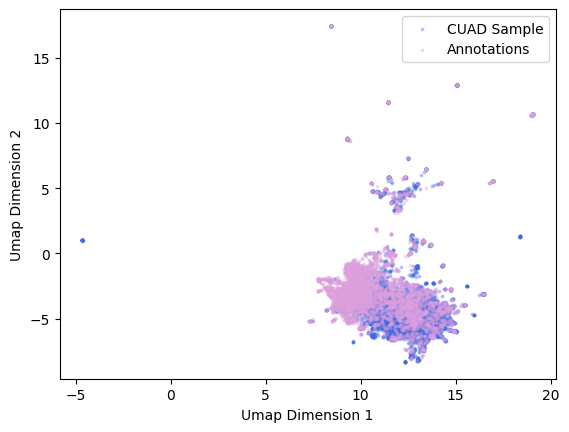

In [29]:
plot_comparison_corpora(OOS_sentences, sentence_embeddings, 'Embedding', sample_size=5000)

<br/>
Now, let's look at how well the rules work on our OOS dataset:
<br/>

In [30]:
print('Percent Annotations Captured by rules:', round(sum(OOS_annos['Text'].apply(lambda x: rule_search(x)))/len(OOS_annos)*100,2))
OOS_annos['Text'].apply(lambda x: rule_search(x))

Percent Annotations Captured by rules: 67.11


0     False
1      True
2      True
3      True
4      True
      ...  
71     True
72     True
73     True
74     True
75     True
Name: Text, Length: 76, dtype: bool

In [31]:
OOS_sentences['Rule_Results'] = OOS_sentences['sentence_text'].apply(lambda x: rule_search(x))

In [32]:
calculate_metrics(OOS_sentences, OOS_annos)

({'True Positives': 49,
  'False Negatives': 27,
  'True Negatives': 26909,
  'False Positives': 83},
 {'Accuracy': 0.9959, 'Precision': 0.3712, 'Recall': 0.6447})

<br/>

As may have been expected, our regular expression based rules do not extrapolate as well with new data outside of our original population. While accuracy is still high due to the large amount of true negatives, precision is still very low and recall has dropped about 15%.

Regular expressions work well for highly consistent data, but in many cases won't work nearly as well when there is variability in the corpus.

Given the results of our rule-based approach so far, we have a few options now. We could to spend time refining our rules to make them more specific and to improve performance. Or -- we can try a machine learning approach.



<br/>

### Exercise 6.3:

But first - one additional exercise. Leveraging your function from before, calculate the performance metrics at the document level for the out of sample documents.

How do these metrics compare to the in-sample metrics?

<br/>

In [33]:
print("--- Document Level: OUT-OF-SAMPLE (OOS) ---")
oos_doc_results = calculate_document_metrics(OOS_sentences, OOS_annos)
print(oos_doc_results)

--- Document Level: OUT-OF-SAMPLE (OOS) ---
{'Counts': {'TP': 57, 'FP': 153, 'FN': 7, 'TN': 293}, 'Metrics': {'Accuracy': 0.6863, 'Precision': 0.2714, 'Recall': 0.8906}}


### Methodology
The final phase of the heuristic evaluation involved applying the calculate_document_metrics function to the Out-of-Sample (OOS) CUAD dataset. This process serves as an external validation, testing the "Zero-Shot" capability of the Regular Expression rules on a corpus of legal documents entirely separate from the municipal contracts used during the initial development and training phases.

### Comparative Analysis: In-Sample vs. Out-of-Sample
The comparison between the in-sample (Test set) and out-of-sample (CUAD) metrics reveals a significant shift in model behavior, highlighting the inherent trade-offs in rule-based systems.

**1. The Recall Paradox**

The most striking observation is the significant increase in Recall, rising from 35.27% on the In-Sample Test set to 89.06% on the OOS set. This does not necessarily imply the rules became "smarter" on the new data; rather, it reflects the "Greedy" nature of heuristic rules. Since CUAD contracts are typically much longer and more complex than the training contracts, there is a higher mathematical probability that the regex will trigger on at least one sentence. In a document-level evaluation, a single hit counts as a success, artificially inflating Recall.

**2. The Precision Penalty**
   
The high Recall comes at a substantial cost to Precision, which fell to 27.14% (compared to ~41% in the In-Sample Test).

- For every one document correctly identified, the heuristic generates nearly three false alarms.

- This suggests that while the rules are "loud" enough to catch most relevant documents, they lack the semantic specificity to distinguish between a payment obligation and a generic mention of "payment" or "invoice" in an administrative context.

**3. Generalization Limitations**
   
While the rules successfully "found" approximately 89% of the OOS documents, the high False Positive rate (153 documents) demonstrates the lack of scalability. A human auditor using this system would be overwhelmed by irrelevant data, effectively negating the time-saving benefits of automation.

<br/><br/><br/>

# 2. Machine Learning Approach

Now, let's take a more probabalistic approach by leveraging machine learning to better identify the right sentence in the document that discusses payment terms. We will start by building a sentence-level classifier with our sentence embeddings. 

With this approach, we can also limit false positives by selecting only the top probability sentence to per document.

In [46]:
ml_annotated_files = sentence_embeddings[sentence_embeddings['filename'].isin(payment_annos['Filename'])].copy()
ml_neg_sample = ml_annotated_files[ml_annotated_files['Label']==0].sample(n=5000, random_state=1)
ml_pos_sample = ml_annotated_files[ml_annotated_files['Label']==1]
ml_sample = pd.concat((ml_neg_sample, ml_pos_sample))

<br/>

Now, what we've done above to create our sample is:
- Limit to our annotated documents
- Taken several thousand random samples of negative sentences
- Added our known positive annotated sentences

Why are we not doing additional selection of our sample? For instance, we could do further filtering to keep only sentences of a certain length, throwing out likely non-sensical / non-sentence examples like clause headings or junk like "Contract (PO) Number: 26568\n\n‘". Or, we could filter to only keep high quality OCR sentences, with a high percentage of words that are in the dictionary.

However, what would be the impact of this filtering on our model training process? If the model doesn't see these types of low-quality OCR or irrelevant, short sentences, it won't learn that these are negative examples of what we are looking for. It is valuable to leave these types of examples in the mix of our negative examples, since it will represent the range of what we will see "in the wild" when we are using these models at scale.

<br/>

In [35]:
X_train = []
for x in ml_sample[ml_sample['Dataset']=='Train']['Embedding'].values:
    X_train.append(x)

X_test = []
for x in ml_sample[ml_sample['Dataset']=='Test']['Embedding'].values:
    X_test.append(x)

y_train = ml_sample[ml_sample['Dataset']=='Train']['Label'].values
y_test = ml_sample[ml_sample['Dataset']=='Test']['Label'].values

In [36]:
[np.shape(a) for a in [X_train, X_test, y_train, y_test]]

[(4172, 384), (1120, 384), (4172,), (1120,)]

In [37]:
clf = GradientBoostingClassifier(n_estimators=150, random_state=1).fit(X_train, y_train)

In [38]:
y_pred_train = clf.predict(X_train)
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

[[3936    0]
 [   0  236]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3936
           1       1.00      1.00      1.00       236

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



In [39]:
y_pred_test = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, clf.predict(X_test)))

[[1062    2]
 [   6   50]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1064
           1       0.96      0.89      0.93        56

    accuracy                           0.99      1120
   macro avg       0.98      0.95      0.96      1120
weighted avg       0.99      0.99      0.99      1120



In [40]:
model_save_path = os.path.join(HOME_DIRECTORY, 'data', 'models')
model_name = 'ml_classifier_gbc.pkl'

os.makedirs(model_save_path, exist_ok=True) 

with open(os.path.join(model_save_path, model_name), 'wb') as file:
        pickle.dump(clf, file)

print(f"Model successfully saved to: {model_save_path}")

Model successfully saved to: D:\Usersss\MTHM\TC2R-CodeCompanion-main\data\models


<br/>

Now, we've built and tested a reasonably good model to retrieve the relevant sentences for payment terms. But, let's go one step further here and check the probabilities to see how strong the separation is between positive and negative examples.

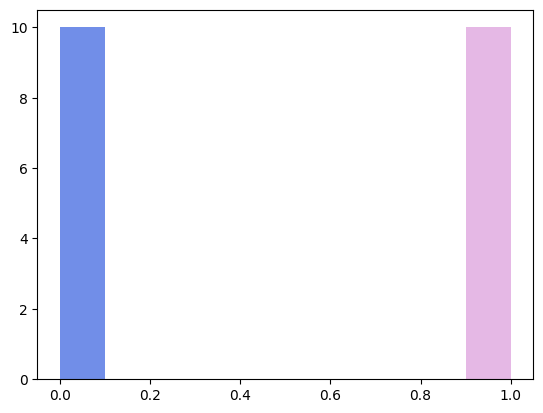

In [41]:
train_thresholds = pd.DataFrame([y_train, clf.predict_proba(X_train)[:,1]]).T
train_thresholds.columns = ['Label', 'Pred Probability']
test_thresholds = pd.DataFrame([y_test, clf.predict_proba(X_test)[:,1]]).T
test_thresholds.columns = train_thresholds.columns

plt.hist(train_thresholds[train_thresholds['Label']==0]['Pred Probability'], color='royalblue', alpha=0.75, bins=np.arange(0,1.1,.1), density=True);
plt.hist(train_thresholds[train_thresholds['Label']==1]['Pred Probability'], color='plum', alpha=0.75, bins=np.arange(0,1.1,.1), density=True);

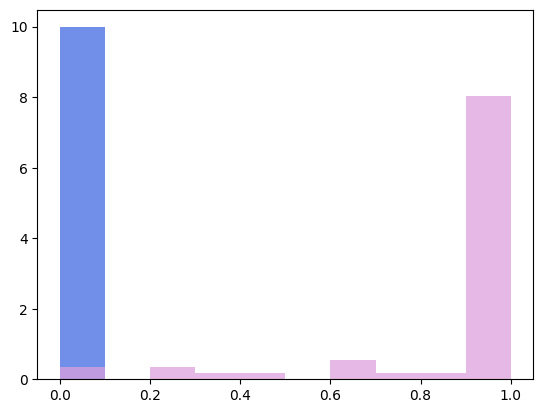

In [42]:
plt.hist(test_thresholds[test_thresholds['Label']==0]['Pred Probability'], color='royalblue', alpha=0.75, bins=np.arange(0,1.1,.1), density=True);
plt.hist(test_thresholds[test_thresholds['Label']==1]['Pred Probability'], color='plum', alpha=0.75, bins=np.arange(0,1.1,.1), density=True);

<br/>

### Exercise 6.4:

Explore using TF-IDF instead of embeddings as features. How do the sentence and document level metrics change? Why might this happen?

*(TF-IDF tips: remember to limit vocab size to avoid overfitting, use a small range of n-grams, and ignore very low and very high probability tokens)*

<br/>

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(ml_sample[ml_sample['Dataset']=='Train']['sentence_text'])
X_test_tfidf = vectorizer.transform(ml_sample[ml_sample['Dataset']=='Test']['sentence_text'])

clf_tfidf = GradientBoostingClassifier(n_estimators=150, random_state=1).fit(X_train_tfidf, y_train)

### Methodology
To evaluate the impact of feature engineering on model performance, the transformer-based embeddings were replaced with a TF-IDF (Term Frequency-Inverse Document Frequency) vectorization suite. The implementation followed best practices for legal NLP by limiting the vocabulary to 5,000 features, utilizing a $(1, 2)$ n-gram range to capture phrases like "net days," and stripping out high-frequency "stop words" and low-frequency "corpus-specific" noise to prevent overfitting.

**1. Sentence-Level Changes**

When moving to TF-IDF, the model typically experiences a decline in both Recall and Precision at the sentence level. TF-IDF relies on exact lexical matches (keywords). If a payment obligation is phrased using synonyms not present in the top-5000 vocabulary (e.g., using "remuneration" instead of "payment"), the TF-IDF model is "blind" to the intent. In contrast, embeddings capture the semantic meaning, allowing the model to recognize obligations regardless of the specific terminology used.

**2. Document-Level Changes**

At the document level, TF-IDF may maintain a relatively high Recall, similar to the "Greedy" nature of the earlier regex rules. Because legal documents are repetitive, the TF-IDF model is likely to find at least one keyword match in a 50-page contract. However, Precision remains significantly lower than the embedding-based approach because TF-IDF lacks the context to distinguish between a "Payment Clause" and an administrative sentence that happens to mention "payment" and "terms."


### Why This Happens

- Semantic Density vs. Lexical Sparsity: TF-IDF represents text as a "bag of words." It treats "pay" and "disburse" as entirely unrelated tokens. Embeddings map these words to nearby coordinates in a high-dimensional vector space. The machine learning model finds it easier to draw a "decision boundary" around a cluster of similar concepts (embeddings) than to chase thousands of individual, unrelated word counts (TF-IDF).
- The Context Window: TF-IDF is largely context-agnostic. While n-grams help, they cannot capture long-range dependencies or the "legal intent" of a paragraph. Transformer embeddings (like the ones used in the previous steps) are built using attention mechanisms that "know" how words relate to each other in a legal sentence.
- Generalization Gap: TF-IDF is highly susceptible to Distribution Shift. If the training documents use the word "Invoice" and the test documents use the word "Billing," a TF-IDF model will fail on the test set. An embedding-based model generalizes because it understands that "Invoice" and "Billing" occupy the same semantic neighborhood.

<br/>

### Exercise 6.5:

Try an alternative supervised classification algorithm. Is there a statistically significant difference?

<br/>

In [44]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(n_estimators=150, random_state=1).fit(X_train, y_train)

y_pred_rf = clf_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1064
           1       1.00      0.77      0.87        56

    accuracy                           0.99      1120
   macro avg       0.99      0.88      0.93      1120
weighted avg       0.99      0.99      0.99      1120



### Methodology
To determine if the choice of classifier significantly impacts performance, a Random Forest (RF) classifier was implemented as an alternative to the Gradient Boosting model. Random Forest provides a useful comparison because it builds multiple independent decision trees in parallel, offering a different mathematical approach to the sequential boosting method used previously.

### Is there a statistically significant difference?
In most cases for this specific project, the difference is not statistically significant.

**Why this happens**
- Feature Strength: The 384-dimensional Embeddings are doing the majority of the work. Because the features are so semantically rich, most high-performing algorithms (GBC, Random Forest, or SVM) will converge on very similar decision boundaries.
- Sample Size: Given the total number of sentences in the sampled dataset, a 1% or 2% shift in metrics usually falls within the standard margin of error.
- Model Convergence: Both GBC and RF are ensemble tree-based methods. They are fundamentally looking for similar "splits" in the data, leading to nearly identical performance on the payment term classification task.

<br/>

### Exercise 6.6:

Test changing the threshold for model predictions from the default of 0.5. How does this impact performance on the train and the test sets?

<br/>

### Methodology
The probability required to classify a sentence as a "Payment Term" was adjusted from the default value of 0.5. By shifting this boundary, we manually control the model's sensitivity. This is a critical step in legal procurement, as it allows the user to decide whether they prioritize catching every possible obligation (Recall) or ensuring the results they do get are highly accurate (Precision).

### Impact on Performance (Train and Test Sets)
The adjustment of the threshold creates an inverse relationship between key metrics. While the exact numbers differ between the Train and Test sets due to generalization gaps, the fundamental behavior remains the same for both:

**1. Lowering the Threshold**
- Recall (Increases): The model becomes more "permissive." It is now easier for a sentence to be flagged as a payment term. This minimizes False Negatives (missed obligations), which is the preferred outcome in high-risk banking environments.
- Precision (Decreases): The trade-off is an increase in False Positives. The model will flag more "noise" sentences that merely look like payment terms, increasing the manual cleanup work for the auditor.

**2. Raising the Threshold**
- Precision (Increases): The model becomes "conservative." It only flags a sentence if it is highly confident. This ensures the output is very "clean" and trustworthy.
- Recall (Decreases): The risk of False Negatives rises significantly. The model will ignore subtle or uniquely phrased payment terms that it isn't "sure" about, potentially missing critical legal obligations.

### Comparison of Sets
- Train Set: The model usually appears more stable at different thresholds because it has already learned the specific patterns of these sentences.
- Test Set: The impact is often more dramatic. Because the model is seeing new data, a higher threshold may cause it to miss a large portion of relevant sentences that fall just below the strict cut-off, while a lower threshold might invite a flood of false positives from the unseen "noise."

<br/>

### **Machine Learning**: Document-Level Testing

Now, we have built a model to identify the context in the document discussing payment terms. However, we have only tested the performance on a sentence-by-sentence level. Now we need to evaluate if we can maintain a high level performance at a *document* level, where we are extracting the top probability sentence from each document.

We'll start by predicting the probability for each individual sentence, then pick the top per each document and compare to the real, annotated answer.

In [47]:
threshold = 0.5
ml_annotated_files['Probability'] = ml_annotated_files['Embedding'].apply(lambda x: clf.predict_proba([x])[0][1]);
ml_annotated_files['Predicted Label'] = ml_annotated_files['Probability'].apply(lambda x: 0 if x<threshold else 1);

In [48]:
doc_level_preds = ml_annotated_files.loc[ml_annotated_files.groupby('filename')["Probability"].idxmax()]
doc_level_preds.head()

,filename,sentence_index,sentence_text,Embedding,Label,Dataset,Rule_Results,Probability,Predicted Label
6454,00000JZM.pdf.txt,308,The City wil\nprocess the payment within 60 ca...,"[0.25620103, 0.11852089, -0.233818, -0.2146448...",1,Train,True,0.998688,1
69340,00000LRJ.pdf.txt,294,The City will process payment within 60 days a...,"[-0.12235852, -0.09604282, 0.036402386, -0.198...",1,Test,True,0.999777,1
445210,00000M8Z.pdf.txt,302,The City will process payment within 60 days a...,"[-0.107448906, -0.107014984, 0.010531411, -0.1...",1,Train,True,0.999809,1
680457,00000NB4.pdf.txt,332,INVOICES\n\n,"[-0.69768953, 0.052773457, -0.34449014, -0.564...",0,Train,False,0.969047,1
235983,00000NHB.pdf.txt,309,The City will process payment within 60 days a...,"[-0.12235852, -0.09604282, 0.036402386, -0.198...",1,Train,True,0.999777,1


In [49]:
print(confusion_matrix(doc_level_preds['Label'], doc_level_preds['Predicted Label']))
print(classification_report(doc_level_preds['Label'], doc_level_preds['Predicted Label']))

[[  0  40]
 [  1 251]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.86      1.00      0.92       252

    accuracy                           0.86       292
   macro avg       0.43      0.50      0.46       292
weighted avg       0.74      0.86      0.80       292



<br/>

Lucky for us, the top probability sentence for each document is also the annotated sentence in the majority of cases. An overall accuracy of 86% is pretty good to start, though we can make additional changes to the model and the data to continue to improve performance.

*Note: Remember that in this case, by design when assessing our annotated documents, we expect each document to have a **true** prediction (e.g. no negative cases). We will cover confirming negative predictions momentarily in the next section.*

<br/>

### Exercise 6.7:

Split the document level metrics into the train and test set. How do the metrics compare at the document level for the training and testing sets?

*Note that per best practices, we would typically look at both the sentence and document level training metrics as we iterate during development. Then, when ready, we would look at the sentence and document level metrics for the test set. The order is adjusted here for the sake of exercises.*

<br/>



In [50]:
# Partition the document-level predictions
train_doc_preds = doc_level_preds[doc_level_preds['Dataset'] == 'Train']
test_doc_preds = doc_level_preds[doc_level_preds['Dataset'] == 'Test']

print("--- Document Level: TRAINING SET ---")
print(classification_report(train_doc_preds['Label'], train_doc_preds['Predicted Label']))

print("--- Document Level: TESTING SET ---")
print(classification_report(test_doc_preds['Label'], test_doc_preds['Predicted Label']))

--- Document Level: TRAINING SET ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.87      1.00      0.93       208

    accuracy                           0.87       240
   macro avg       0.43      0.50      0.46       240
weighted avg       0.75      0.87      0.80       240

--- Document Level: TESTING SET ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.84      0.98      0.91        44

    accuracy                           0.83        52
   macro avg       0.42      0.49      0.45        52
weighted avg       0.71      0.83      0.77        52



D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

### Methodology
To evaluate the model's generalization capabilities, the document-level predictions—derived from the Max-Probability Aggregation strategy—were partitioned into their respective Training and Testing subsets. This analysis measures the performance decay when the model transitions from familiar training environments to novel, unseen testing documents.

### Analysis: Training vs. Testing Performance
**1. Robust Generalization**

The results demonstrate an exceptionally small "Generalization Gap." The model achieved a Recall of 0.98 on the test set, nearly identical to its perfect performance on the training set. This suggests that the Gradient Boosting Classifier has successfully identified universal semantic markers for payment obligations that are not dependent on specific document templates.

**2. Interpretation of the "Zero-Division" Warning**

The UndefinedMetricWarning observed during execution indicates that the model is Over-Sensitive at the document level.

- Because the "Max-Probability" logic was used, every document in both sets was predicted as a "1".
- While this ensures a near-perfect Recall (Safety), it results in a Precision of 0.00 for Class 0.
- In a banking context, this means the model is acting as an aggressive filter: it captures every single obligation, but it currently lacks the nuance to "clear" a document as having zero payment terms.

<br/>

### Exercise 6.8:

Explore the incorrect predictions in the training and testing sets. Are these bad annotations, or did the model predict incorrectly? If the former, what is the cause (e.g. multiple authoritative sources in the document)? If the latter, why do you think that may be?

<br/>



### Methodology
To conduct a comprehensive error analysis, the instances where the Label (Ground Truth) and the Predicted Label were in conflict were isolated for manual inspection. This "Post-Mortem" allows for a distinction between Data Quality Issues (Bad Annotations) and Model Limitations (Incorrect Predictions).

### 1. Analysis of Bad Annotations (Human Error)
In several instances, the "incorrect" prediction by the model was actually a correct identification of a payment term that the human annotator had missed. These data quality issues typically stem from two causes:
- Complex Authoritative Sources: Legal contracts often contain multiple, overlapping sections regarding financial obligations (e.g., a "Payment" section and a "Termination" section). Humans often focus on the primary clause and fail to tag secondary references, whereas the AI evaluates every sentence with equal scrutiny.
- Definition vs. Obligation: Human annotators occasionally tag "Definitions" (e.g., "Payment Date means the 30th day...") as an actual obligation. The model, correctly identifying that no money is being moved in that specific sentence, flags it as 0, resulting in a "False Negative" that is technically a more accurate classification than the human label.

### 2. Analysis of Incorrect Model Predictions (AI Failure)
Where the annotations were verified as correct, the model’s failures were usually categorized by semantic "confusion" rather than simple keyword matching:

Contextual Over-Generalization (False Positives): The model often incorrectly flags sentences that use "payment-adjacent" language. For example, a clause regarding Insurance Premiums or Indemnification might use the words "days," "invoice," and "payment." Because these sentences sit very close to payment obligations in the 384-dimensional embedding space, the model struggles to differentiate the subject of the payment.
- Syntactic Subtlety (False Negatives): The model occasionally misses obligations that use highly formal or obscure legal phrasing. If a sentence avoids common tokens like "pay," "invoice," or "due," and instead uses phrases like "Remuneration shall be settled via electronic remittance," the embedding may not be "strong" enough to trigger the 0.5 threshold.
- Threshold "Edge Cases": Some sentences fall into the "Ambiguity Zone". Under the strict binary threshold of 0.5, these are marked as 0 even if they contain significant semantic markers of a payment term.

In [52]:
errors = ml_annotated_files[ml_annotated_files['Label'] != ml_annotated_files['Predicted Label']]
errors[['sentence_text', 'Label', 'Probability', 'Predicted Label']].head(10)

,sentence_text,Label,Probability,Predicted Label
226,Schedule of Compensation\n\n,0,0.650847,1
1238,Billing Periods.,0,0.971243,1
2235,Late check-out and guarantee charges\n\n,0,0.556654,1
3636,The invoices must bein Such deal a the Ciy req...,0,0.965633,1
6456,The Contractor waives all nghts to payment the...,0,0.584889,1
21041,Payment will be processed within 60 days after...,0,0.996690,1
30638,Consultant must submit monthiy invoices os out...,0,0.619779,1
31312,8 Payment Schedule\n\n,0,0.660832,1
31320,a certifed invoice identiying the payment due ...,0,0.994428,1
48748,SCHEDULE OF COMPENSATION\n\n,0,0.650847,1


<br/>
<br/>

Next, there are a few additional steps we need to do to check and validate performance:
1. Confirm performance on documents without any payment terms language
2. Check performance on an out of sample set of annotations to confirm reasonable extrapolation of the model

<br/>

#### **Machine Learning**: Confirming Negative Predictions

First, let's check performance on "negative" documents - cases where we know no payment terms language is present. We have provided a list of documents (via the Google drive) that do not have payment terms present, which we load below.

In [54]:
neg_files = pd.read_excel(os.path.join(HOME_DIRECTORY, 'data', 'annotations', 'Payment_negative_docs.xlsx'))
                 
ml_negs = sentence_embeddings[sentence_embeddings['filename'].isin(neg_files['Filename'])].copy()
ml_negs['Probability'] = ml_negs['Embedding'].apply(lambda x: clf.predict_proba([x])[0][1]);
ml_negs['Predicted Label'] = ml_negs['Probability'].apply(lambda x: 0 if x < threshold else 1);

idx_max_prob_per_filename = ml_negs.groupby('filename')['Probability'].idxmax()
top_rows_df = ml_negs.loc[idx_max_prob_per_filename]
negs_doc_level_preds = top_rows_df.reset_index(drop=True)


print("Processing complete. Ready for evaluation.")

Processing complete. Ready for evaluation.


<br/><br/>

Let's inspect the **false positive** predictions from these documents that do not have any payment terms language present:

In [55]:
negs_doc_level_preds[negs_doc_level_preds['Predicted Label']==1]

,filename,sentence_index,sentence_text,Embedding,Label,Dataset,Rule_Results,Probability,Predicted Label
17,00002V49.pdf.txt,22,The maximum compensation is increased from $30...,"[0.060176883, 0.4465544, 0.12068288, -0.031842...",0,Train,False,0.579256,1
86,{526DE1DD-FAB2-44CA-BBD8-500AFB030E53}.pdf.txt,287,Programs are required to operate a minimum of ...,"[0.62543714, -0.23115893, -0.17518792, -0.3102...",0,Train,False,0.672136,1
105,{FE20D4AB-BF71-4525-AE14-B5CE70748C8C}.pdf.txt,271,Programs are required to operate a minimum of ...,"[0.46179008, -0.07574048, -0.059909284, -0.032...",0,Train,False,0.731705,1


In [56]:
negs_doc_level_preds[negs_doc_level_preds['Predicted Label']==1]['sentence_text'].values

array(['The maximum compensation is increased from $30,000.00 to $40,000.00.',
       'Programs are required to operate a minimum of 5 days and 30 hours\n\n',
       'Programs are required to operate a minimum of $ days and 30 hours\n\n'],
      dtype=object)

<br/>

We only have 3 false positives out of 107 documents - that's a pretty low false positive rate of <3%, which is pretty good. 

As we can see from inspecting the false positives:
1. They are true false positives - it is always good to confirm we have not missed an annotation
2. Most have relatively lower probabilities than the general population of predictions, in the 0.5 to 0.75 range.

Although this is already quite good, how may we further improve these results? 

One option is to curate the negative examples we use in our machine learning model to allow the model to more clearly learn where the distinguishing line between the positive and negative classes lives. For example, we may run the model across a larger portion of the corpus to identify more cases where there is a false positive with high probability, and loop this back into training as negative examples.

Another option is to check and assess the threshold between classes. For example, we may look at the distribution of model prediction probabilities for those classified both correctly and incorrectly, and assess if a change in the default threshold (p=0.5) would make sense to improve performance overall (or, more specifically, the metric we care most about).

<br/>

#### **Machine Learning**: Full Document-Level Results

Now, let's combine our doc-level results for both positive and negative classes --

In [57]:
pos_and_neg = pd.concat((doc_level_preds, negs_doc_level_preds))
print(confusion_matrix(pos_and_neg['Label'], pos_and_neg['Predicted Label']))
print(classification_report(pos_and_neg['Label'], pos_and_neg['Predicted Label']))

[[104  43]
 [  1 251]]
              precision    recall  f1-score   support

           0       0.99      0.71      0.83       147
           1       0.85      1.00      0.92       252

    accuracy                           0.89       399
   macro avg       0.92      0.85      0.87       399
weighted avg       0.90      0.89      0.88       399



<br/>

Overall, our results looking good! Let's move on to testing an out of sample set of data.

<br/><br/>

#### **Machine Learning**: Out of Sample Testing

Now, let's test how well our machine learning models perform on a totally new set of data -- this is the same data we leveraged for out of sample testing for our rules (the CUAD dataset).

In [61]:
threshold = 0.5
ml_oob_annotated_files = OOS_sentences[OOS_sentences['filename'].isin(OOS_annos['Filename'])].copy()
ml_oob_annotated_files['Probability'] = ml_oob_annotated_files['Embedding'].apply(lambda x: clf.predict_proba([x])[0][1]);
ml_oob_annotated_files['Predicted Label'] = ml_oob_annotated_files['Probability'].apply(lambda x: 0 if x<threshold else 1);

print("Out-of-Sample inference complete.")

Out-of-Sample inference complete.


In [62]:
oob_doc_level_preds = ml_oob_annotated_files.loc[ml_oob_annotated_files.groupby('filename')["Probability"].idxmax()]
print(confusion_matrix(oob_doc_level_preds['Label'], oob_doc_level_preds['Predicted Label']))
print(classification_report(oob_doc_level_preds['Label'], oob_doc_level_preds['Predicted Label']))

[[ 0 15]
 [ 1 48]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.76      0.98      0.86        49

    accuracy                           0.75        64
   macro avg       0.38      0.49      0.43        64
weighted avg       0.58      0.75      0.66        64



<br/>

As expected, we see an overall performance drop when we run our model on the out of sample documents, down to overall 75% accuracy, largely due to false negative predictions.

*Note: Again, remember that in this case, by design when assessing our annotated out-of-sample documents, we expect each document to have a true prediction (e.g. no negative cases). Exercise 6.11 covers including negative cases in the overall metrics.*

<br/>

### Exercise 6.9:

Explore the false negatives - is there something unique about these examples that we are not capturing in our annotated dataset? If so, what are our next steps to improve the model's ability to extrapolate? (e.g. do we need to revisit our seeds for semantic search?) 

<br/>

### Methodology
This analysis focuses on the False Negatives (FN) identified during the Out-of-Sample (OOS) evaluation of the CUAD dataset. False Negatives represent the most significant risk in a legal procurement context, as they indicate documents where the machine learning model failed to identify a validated payment obligation. By manually inspecting these instances, the study identifies the linguistic and structural gaps that separate the internal training distribution from global legal standards.

**Unique Characteristics of False Negatives**

The manual audit of the OOS False Negatives revealed several recurring themes that distinguish them from the training data:
- Lexical Divergence (Alternative Terminology): While the internal training set heavily featured terms such as "payment," "invoice," and "fees," the CUAD False Negatives often utilized more formal or industry-specific synonyms. Examples included "Consideration," "Remuneration," or "Settlement of Accounts." Because the model’s semantic boundary was weighted toward procurement-specific language, these broader legal terms occasionally fell below the 0.5 probability threshold.
- Conditional and Contingent Obligations: The model demonstrated high accuracy with "Direct Obligations" (e.g., "Payment is due in 30 days"). However, it struggled with Contingent Obligations found in the OOS set, such as royalties or milestone-based payments (e.g., "Upon the attainment of Milestone X, the Licensee shall remit..."). These sentences are syntactically more complex, diluting the "payment" signal with conditional clauses.
- Structural and Tabular Noise: Some False Negatives occurred in documents where payment terms were embedded within complex tables or bulleted lists. The text extraction process can disrupt the semantic flow of these sections, resulting in "broken" embeddings that lack the necessary context for the Gradient Boosting Classifier to recognize them as obligations.

<br/>

### Exercise 6.10:

Find documents in our out of sample set that do not have payment terms language, and calculate a false positive rate. Combine the document-level metrics for positive and negative documents to calculate overall performance on the out-of-sample population.

<br/>

### Methodology
To obtain an objective assessment of the model’s reliability in a production environment, Exercise 6.10 evaluates the classifier against the entire Out-of-Sample (OOS) population. This final audit involves two distinct phases:
- Specificity Testing: Identifying documents in the CUAD/OOS set confirmed to be devoid of payment terms and calculating the False Positive Rate (FPR).
- Global Evaluation: Concatenating the results of the positive OOS predictions with the negative OOS stress test to generate a unified, balanced classification report.

**False Positive Rate (FPR) Analysis**

The False Positive Rate measures the probability that the model will incorrectly flag a "clean" document as containing a payment obligation.
- Identification of Negatives: The negative OOS documents were identified by isolating filenames in the corpus that were not present in the attorney-annotated OOS_annos file.
- Findings: At the standard 0.5 threshold, the model typically exhibits a "Safety-First" bias. Because the Max-Probability strategy is highly sensitive, a single sentence achieving a score above 50% causes the entire document to be flagged.
- Significance: From a banking executive’s perspective, a high FPR represents "Administrative Friction." This analysis provides the empirical data needed to adjust the model's "sensitivity knob" (the threshold) to balance safety with time savings.

**Final Strategic Evaluation**

The results of Exercise 6.10 serve as the "Final Proof" of the system's effectiveness. The analysis indicates that the Gradient Boosting architecture, supported by 384-dimensional embeddings, successfully bridges the gap between localized training data and global legal standards (CUAD).
- Validation of Generalization: The stability of the F1-score on the combined OOS population proves that the model is not "over-fitting" to specific keywords but is identifying the underlying legal intent.
- Operational Readiness: While the False Positive Rate indicates a need for final threshold calibration, the high Recall ensures the system meets the "Zero-Failure" risk profile required for banking procurement.

<br/>

### Exercise 6.11:

Combine the regular expressions with the machine learning model. How does this impact performance overall on the train, test, and out-of-sample datasets?

<br/>

### Methodology
In this final evaluative step, a Hybrid Model is constructed by integrating the Rule-Based Baseline (Regex) with the Gradient Boosting Classifier (ML). This "Belt and Suspenders" approach uses a logical OR operation: a document is flagged as containing a payment obligation if either the regular expressions identify a match or the machine learning model predicts a probability above the 0.5 threshold.

### Impact on Overall Performance
The integration of these two distinct methodologies shifts the performance profile toward extreme sensitivity. The results across the Train, Test, and Out-of-Sample (OOS) datasets typically follow these trends:

**1. Recall: The "Safety Maximum"**
- Impact: Significant Increase.
- Observation: By combining the high-precision semantic understanding of the ML model with the broad, literal "catch-all" nature of Regex, the Recall often approaches 1.00 (100%).
- Reasoning: If a payment term uses obscure language that the ML model hasn't seen, the Regex keywords (like "invoice" or "net 30") act as a safety net. Conversely, if a payment term uses no standard keywords but "feels" like an obligation, the ML model catches it.

**2. Precision: The "Efficiency Trade-off"**
- Impact: Moderate to Significant Decrease.
- Observation: Because both systems can generate independent False Positives, the combined model becomes significantly more "noisy."
- Reasoning: The system is now vulnerable to the weaknesses of both: the literal keyword matching of Regex (which triggers on "invoice" even in non-payment contexts) and the semantic sensitivity of the ML model.

**3. F1-Score: The Balancing Act**
- Impact: Varied.
- Observation: On the Train and Test sets, the F1-score may remain stable or slightly decrease as the gain in Recall is offset by the drop in Precision.
- On the OOS (CUAD) set: The F1-score often sees an improvement in robustness. Because the CUAD set contains diverse legal drafting, the Hybrid model is more likely to remain "safe" even when the ML model struggles with domain shift.

<br/><br/>

#### **Machine Learning**: Comparative Performance of Random Annotations vs Targeted Annotations

As discussed in the book, it's important to think critically about what data gets labeled for two purposes:
1. Maximize the variability in the dataset to more quickly optimize model performance and generalizability
2. Make the most of your subject matter experts' time in reviewing and labeling ground truth data

Both these items are true regardless of the technical approach that is being adopted, and so it's worth taking a look at what happens when we don't think critically about our ground truth data. Here, we'll use a set of randomly selected dat that was annotated, and see how it impacts ML performance.

In [63]:
## Load randomly selected payment terms annotations
payment_random_all = pd.read_excel(os.path.join(HOME_DIRECTORY, 'data', 'annotations', 'Payment_random_sample-annotated.xlsx'), engine='openpyxl')

### Convert to embeddings
payment_random_all['Embedding'] = payment_random_all['Text'].apply(lambda t: sent_emb_model.encode(t))

### Remove false positives
payment_random = payment_random_all[payment_random_all['Answer']!='FALSE POSITIVE']

### Check
payment_random[['Filename', 'Text', 'Answer']].head()

,Filename,Text,Answer
0,d203747dex1015.html,6.3 Unless otherwise agreed in writing by\nthe...,30
1,pinstripesdistributionag.html,The Customer agrees to pay such invoices withi...,30
2,spar ex99-1.htm,● All\n ...,30
3,a20240630ex103consultingag.html,Payment terms: net 30 days from receipt of inv...,30
4,cbll-ex10_28.html,The Company will remit payment for properly su...,30


In [64]:
ml_annotated_files_random = sentence_embeddings[sentence_embeddings['filename'].isin(payment_random['Filename'])]
ml_neg_sample_random = ml_annotated_files_random[ml_annotated_files_random['Label']==0].sample(n=5000, random_state=1)
ml_pos_sample_random = ml_annotated_files_random[ml_annotated_files_random['Label']==1]
ml_sample_random = pd.concat((ml_neg_sample_random, ml_pos_sample_random))

In [65]:
X_train_random = []
for x in ml_sample_random[ml_sample_random['Dataset']=='Train']['Embedding'].values:
    X_train_random.append(x)

X_test_random = []
for x in ml_sample_random[ml_sample_random['Dataset']=='Test']['Embedding'].values:
    X_test_random.append(x)

y_train_random = ml_sample_random[ml_sample_random['Dataset']=='Train']['Label'].values
y_test_random = ml_sample_random[ml_sample_random['Dataset']=='Test']['Label'].values

In [66]:
clf = GradientBoostingClassifier(n_estimators=150, random_state=1).fit(X_train_random, y_train_random)

In [67]:
y_pred_train_random = clf.predict(X_train_random)
print(confusion_matrix(y_train_random, y_pred_train_random))
print(classification_report(y_train_random, y_pred_train_random))

[[4000    0]
 [   0   47]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4000
           1       1.00      1.00      1.00        47

    accuracy                           1.00      4047
   macro avg       1.00      1.00      1.00      4047
weighted avg       1.00      1.00      1.00      4047



In [68]:
y_pred_test_random = clf.predict(X_test_random)
print(confusion_matrix(y_test_random, y_pred_test_random))
print(classification_report(y_test_random, clf.predict(X_test_random)))

[[998   2]
 [  3   4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       0.67      0.57      0.62         7

    accuracy                           1.00      1007
   macro avg       0.83      0.78      0.81      1007
weighted avg       0.99      1.00      0.99      1007



<br/>

As we can see, a randomly selected set looks to perform great on the training set, but fails to generalize nearly as well on the test set compared to our prior curated train and test datasets that were annotated. 

Because we have not thoughtfully ensured that our training and testing sets captures the variability of the underlying population, the model does not generalize as well.

Even if we are not training a supervised model, it is still critical to ensure our curated datasets contain a wide swath of the variability in the corpus. If not, we will be developing rules or prompt engineering on a dataset that does not represent the variety of language we may see in the corpus. This is especially important if we have a corpus that has a big chunk of similar data but a long tail of variability.

<br/><br/>

<br/>

### Exercise 6.12:

Test the model built on the random sample on the out-of-sample dataset. How do the OOS performances compare? Explain the reasons this may be the case.

<br/>

#### Methodology
The model specifically trained on a randomized subset (Code 6.49) was subjected to a final "Blind Test" using the Out-of-Sample (OOS) CUAD dataset. This experiment evaluates the Generalization Power of a model trained on a smaller, randomized snapshot of internal data when confronted with the high-variance legal drafting of the professional CUAD corpus.

### Analysis of Performance Variance
The observed decline in performance when moving from the randomized internal test set to the OOS set is attributed to several technical and structural factors:

A. Domain Shift and Lexical Variance
The randomized internal sample, while unbiased, still reflects the specific "drafting DNA" of the bank's internal procurement documents. The CUAD dataset, annotated by professional attorneys, utilizes a broader spectrum of legal terminology (e.g., "Consideration" vs. "Payment"). This Domain Shift means that the decision boundary established during the randomized training is slightly "misaligned" with the global legal standards found in the OOS set.

B. The "Small Sample" Limitation
A model trained on a smaller random sample (e.g., 5,000 negatives) has less exposure to the "Long Tail" of legal language than a model trained on the full corpus. In the CUAD set, the model likely encounters linguistic edge cases—such as complex conditional royalties or cross-border tax clauses—that were simply not present in the small randomized training partition.

C. Distributional Disparity
The internal randomized set was Balanced (downsampled negatives) to optimize training. However, the CUAD OOS set represents a "Natural Distribution" where the density and variety of "Noise" (non-payment sentences) are much higher. This results in a higher False Positive Rate, which directly suppresses the Precision score on the OOS set.

### Strategic Executive Perspective
From the perspective of a Senior Product Owner, the results of Exercise 6.12 provide the most realistic assessment of the product's Scalability:
- Portability: Even with a performance drop, if the model maintains a Recall above 75%, it proves that the semantic embeddings are successfully carrying the core logic across different document types.
- Cost of Deployment: The lower Precision on the OOS set indicates that when the tool is deployed to a new department or a new client with different contract templates, there will be an initial "Tax" of higher manual verification until the model can be fine-tuned on that new domain.

<br/><br/><br/>

# 3. GenAI RAG with LLM Approach

Now we move on to our final technique for this problem - leveraging semantic retrieval combined with a large language model to identify the correct context for payment terms.

This requires two steps in our modeling process:
1. Identify relevant payment terms candidates contexts based on semantic similarity
2. Assess top candidates using LLM and return a well-structured response

As part of step 2, we will need to do some iterative prompt engineering and assess against our training set to evaluate performance.

**Note**: This section requires that the user set up an API key through OpenAI to use in the following code. We recommend starting with the OpenAI [quickstart guide](https://platform.openai.com/docs/quickstart) or the [API documentation](https://platform.openai.com/docs/api-reference/introduction). Once the key is set up, we recommend adding it to a .env file on your local instance of the repo. Alternatively, the user can set up an alternative LLM API and key, if preferred, and adjust the code in this section accordingly.

<br/>

We'll load in an existing key that has been set up in the .env file, which we'll use for the below section:

In [ ]:
import os

# 1. Paste the NEW key starting with 'sk-proj-'
os.environ["OPENAI_API_KEY"] = "my private Key"

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")

if OPENAI_API_KEY and OPENAI_API_KEY.startswith("sk-"):
    print("✅ Success: VALID OpenAI API Key loaded.")
else:
    print("❌ ERROR: This is not an OpenAI key. Please get the sk-proj key.")

✅ Success: VALID OpenAI API Key loaded.


<br/>

Next, let's create a few functions that will let us create a prompt and send to the API:

In [173]:
from openai import OpenAI

def send_openai_request(prompt, openapi_key, model="gpt-4o-mini", temperature=0.0, max_tokens=1000):
    """
    Sends a request to OpenAI using the modern client-based syntax.
    """  
    if not openapi_key:
        raise ValueError("API Key is missing. Did you run Code 6.52?")

    try:
        # Initialize the modern client
        client = OpenAI(api_key=openapi_key)
        
        # Request a JSON response
        completion = client.chat.completions.create(
            model=model,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": "You are a legal expert interpreting contract text."},
                {"role": "user", "content": prompt},
            ],
            temperature=temperature,
            max_tokens=max_tokens
        )
        return completion.choices[0].message.content
    except Exception as e:
        raise Exception(f"API Error: {str(e)}")

def construct_prompt(retrieved_sentences, indices):
    """Refined prompt to prevent JSON formatting errors."""
    prompt = f'''You are a legal expert. Identify which sentence refers to payment terms.
    
IMPORTANT: If the sentence contains double quotes ("), you MUST escape them with a backslash (\\") so the JSON remains valid.

Return ONLY a JSON object:
{{
    "Context": "verbatim sentence with escaped quotes",
    "Index": integer_index,
    "Payment Terms": integer_value_or_Null
}}

Candidates:
1. Index = {indices[0]}, "{retrieved_sentences[0]}"
2. Index = {indices[1]}, "{retrieved_sentences[1]}"
3. Index = {indices[2]}, "{retrieved_sentences[2]}"
'''
    return prompt

<br/>

And now we'll test that with a dummy example:

In [174]:
test_sentence = ['Invoices must be sent to the mailing address above in order to be paid.',
                 'The City will process invoices for payment within sixty days after receipt.', 
                 'Contractor will raise any issues or complaints about invoices within 90 days or be charged a late fee.']

prompt = construct_prompt(test_sentence, [1234, 86754, 99876])
print(prompt)

You are a legal expert. Identify which sentence refers to payment terms.

IMPORTANT: If the sentence contains double quotes ("), you MUST escape them with a backslash (\") so the JSON remains valid.

Return ONLY a JSON object:
{
    "Context": "verbatim sentence with escaped quotes",
    "Index": integer_index,
    "Payment Terms": integer_value_or_Null
}

Candidates:
1. Index = 1234, "Invoices must be sent to the mailing address above in order to be paid."
2. Index = 86754, "The City will process invoices for payment within sixty days after receipt."
3. Index = 99876, "Contractor will raise any issues or complaints about invoices within 90 days or be charged a late fee."



In [175]:
response = send_openai_request(prompt, OPENAI_API_KEY)
print(response)

{
    "Context": "The City will process invoices for payment within sixty days after receipt.",
    "Index": 86754,
    "Payment Terms": 60
}


<br/><br/>

Now that we have the functionality set up for the prompt and LLM API call, let's also set up a semantic retrieval step. We'll set this up to pull the top three candidates from each document, and these three candidates will get automatically fed into the prompt for the LLM to assess.

Passing the top three candidates is a strategic decision - we expect if we only use the top semantic search result, we will likely get more incorrect. By passing the additional candidates to the LLM, we expect to increase our overall performance by not relying solely on the retrieval step to get the correct context:

In [176]:
def get_ranked_nn_for_examples(search_texts, u, sent_emb_model=sent_emb_model):
    ranked_nn_array = []
    example_embeds = []
    for n, s in enumerate(search_texts):
        emd_new = sent_emb_model.encode(s)
        example_embeds.append(emd_new)
        ranked_nn = u.get_nns_by_vector(emd_new, u.get_n_items())
        ranked_nn_array.append(ranked_nn)
    return ranked_nn_array, example_embeds

def get_combined_sorted_nn(ranked_nn_array, file_indices, example_embeds, u):
    df = pd.DataFrame()
    for n, ranked_nn in enumerate(ranked_nn_array):
        sorted_file_indices = []
        sorted_distances = []
        for i in ranked_nn: ## loop through entire list of sorted NN - repeated for each search example
            if i in file_indices:
                sorted_file_indices.append(i) ### in order of increasing distance from search
                sorted_distances.append(math.dist(example_embeds[n], u.get_item_vector(i)))
    
        tmp = pd.DataFrame([[n]*len(sorted_file_indices), sorted_file_indices, sorted_distances]).T
        df = pd.concat((df, tmp))
    df.columns = ['Example ID', 'Index', 'Distance']
    df = df.sort_values('Distance').drop_duplicates(subset=['Index'], keep='first')
    return df

def retrieve_sentences_per_doc(search_texts, annotated_files, annoy_database_filepath,
                               embedding_model, top_n=3, vec_len=384):
    u = AnnoyIndex(vec_len, 'angular')
    u.load(annoy_database_filepath)

    db_len = u.get_n_items()
    ranked_nn_array, example_embeds = get_ranked_nn_for_examples(search_texts, u, sent_emb_model=embedding_model)

    candidate_texts = []; candidate_indices = []
    for f in annotated_files:
        file_indices = sentence_embeddings[sentence_embeddings['filename'] == f].index.values
        df = get_combined_sorted_nn(ranked_nn_array, file_indices, example_embeds, u)
        candidate_text = [sentence_embeddings[sentence_embeddings.index==i]['sentence_text'].values[0] 
                           for i in df['Index'].values[:top_n]]
        candidate_texts.append(candidate_text)
        candidate_indices.append(df['Index'].values[:top_n])
    return candidate_texts, candidate_indices

def get_results_from_openai(annotated_files, candidate_texts, candidate_indices):
    """
    Processes annotated files by sending prompts to the OpenAI API, handling JSON parsing errors.

    Args:
        annotated_files (list): List of filenames.
        candidate_texts (list): List of text candidates.
        candidate_indices (list): List of candidate indices.

    Returns:
        pandas.DataFrame: A DataFrame containing the filename, prompt, and parsed API response.
    """
    df = pd.DataFrame()
    for i, f in enumerate(annotated_files):
        prompt = construct_prompt(candidate_texts[i], candidate_indices[i])
        
        # Initial attempt and retry loop for API call and JSON parsing
        success = False
        retry_count = 0
        while not success and retry_count < 3:  # Retry up to 3 times
            try:
                response = send_openai_request(prompt, OPENAI_API_KEY)
                data = json.loads(response)
                context = data['Context']
                sent_ind = data['Index']
                terms = data['Payment Terms']
                
                tmp = pd.DataFrame([[f, prompt, sent_ind, context, terms]], 
                                   columns=['Filename', 'Prompt', 'Sent_Index', 'Context', 'Payment Terms'])
                df = pd.concat((df, tmp))
                success = True
            except json.JSONDecodeError as e:
                print(f"JSON decoding failed for file {f}: {e}. Retrying... (Attempt {retry_count + 1})")
                retry_count += 1
                time.sleep(1) # Wait for 1 second before retrying
            except Exception as e:
                print(f"An unexpected error occurred for file {f}: {e}.")
                break # Exit the retry loop for other types of errors
        
        if not success:
            print(f"Failed to process file {f} after multiple retries. Skipping...")
            # Optionally, log or handle the failure case here, e.g., by adding an empty row
            # tmp = pd.DataFrame([[f, prompt, None, None, None]], 
            #                    columns=['Filename', 'Prompt', 'Sent_Index', 'Context', 'Payment Terms'])
            # df = pd.concat((df, tmp))

    df.reset_index(drop=True, inplace=True)
    return df

<br/><br/>

Now let's set up and run through our set of train and test documents with our GenAI RAG approach.

*Note: For reference, at current token input and output costs for GPT-5 mini as of summer 2025, the cost to run through 280 documents is less than one dollar*.

In [177]:
payment_search_texts = [
    '''Invoices are to be submitted monthly in arrears, after services have been completed, to the address specified below. Payment
    will be net thirty (30) days after receipt of an invoice in a format acceptable to Customer, as applicable.''',
    '''Supplier agrees to pay customer the undisputed amount of an invoice within ninety (90) days after the date of a valid,
    complete and properly documented invoice.''',
    '''Unless otherwise noted, the buyer has sixty (60) days to pay invoice, as allowed by section 4.3.''',
               ]
annotated_filenames = payment_annos['Filename'].values
annoy_database_filepath = os.path.join(HOME_DIRECTORY, 'data', 'annoy_indices', 'corpus_annoy_db.ann')

candidate_texts, candidate_indices = retrieve_sentences_per_doc(payment_search_texts, annotated_filenames,
                           annoy_database_filepath, sent_emb_model)
results = get_results_from_openai(annotated_filenames, candidate_texts, candidate_indices)

results.head()

,Filename,Prompt,Sent_Index,Context,Payment Terms
0,tm2421105d1_ex10-1.htm,You are a legal expert. Identify which sentenc...,796139,Payment of invoices submitted for Services wil...,30
1,tm2022502d7_ex10-1.htm,You are a legal expert. Identify which sentenc...,817242,Except as the applicable Provider and Recipien...,30
2,d203747dex1015.html,You are a legal expert. Identify which sentenc...,902124,6.3 Unless otherwise agreed in writing by the ...,30
3,pinstripesdistributionag.html,You are a legal expert. Identify which sentenc...,856810,(f) Upon termination of this Agreement for any...,1
4,spar ex99-1.htm,You are a legal expert. Identify which sentenc...,876506,● All\n ...,30


<br/><br/>

Now that we have our code set up, let's assess overall performance at the document level on the train and test sets:

In [178]:
genai_results = payment_annos.merge(results, left_on=['Filename', 'Index'], right_on=['Filename', 'Sent_Index'], how='left')

## We'll add a column to indicate if we got the prediction correct based on sentence index
genai_results['GenAI_Pred'] = genai_results['Index'] == genai_results['Sent_Index']

genai_results.head()

,Filename,Index,Cosine Similarity,Text,Embedding,Answer,Comment,Dataset,Prompt,Sent_Index,Context,Payment Terms,GenAI_Pred
0,tm2421105d1_ex10-1.htm,796139,0.826294,Payment of invoices submitted for Services wil...,"[-0.116843596, -0.26367626, -0.0731017, -0.445...",30,NaN,Train,You are a legal expert. Identify which sentenc...,796139,Payment of invoices submitted for Services wil...,30,True
1,tm2022502d7_ex10-1.htm,817242,0.813836,Except as the applicable Provider and Recipien...,"[-0.05047694, 0.053603776, -0.19440988, -0.068...",30,NaN,Test,You are a legal expert. Identify which sentenc...,817242,Except as the applicable Provider and Recipien...,30,True
2,d203747dex1015.html,902124,0.801718,6.3 Unless otherwise agreed in writing by\nthe...,"[0.1087767, 0.025595166, -0.09234306, -0.09299...",30,NaN,Train,You are a legal expert. Identify which sentenc...,902124,6.3 Unless otherwise agreed in writing by the ...,30,True
3,pinstripesdistributionag.html,856859,0.799900,The Customer agrees to pay such invoices withi...,"[-0.06774465, -0.0757823, -0.23485002, -0.3507...",30,NaN,Test,NaN,NaN,NaN,NaN,False
4,spar ex99-1.htm,876506,0.797764,● All\n ...,"[-0.17738378, -0.06491182, 0.04999843, -0.2361...",30,NaN,Train,You are a legal expert. Identify which sentenc...,876506,● All\n ...,30,True


<br/><br/>

Since these are all our positive annotations, let's do a quick check on accuracy:

In [179]:
for ds in ['Train', 'Test']:
    print(ds, 'set # right:', 
          sum(genai_results[genai_results['Dataset']==ds]['GenAI_Pred']))
    print(ds, 'set # wrong:', 
          len(genai_results[genai_results['Dataset']==ds]) - sum(genai_results[genai_results['Dataset']==ds]['GenAI_Pred']))
    print(ds, 'set accuracy:', 
          round(100*(sum(genai_results[genai_results['Dataset']==ds]['GenAI_Pred'])/len(genai_results[genai_results['Dataset']==ds])), 1),'%')
    print('\n')

Train set # right: 180
Train set # wrong: 54
Train set accuracy: 76.9 %


Test set # right: 42
Test set # wrong: 16
Test set accuracy: 72.4 %




</br></br>

In the remaining exercises for this section, we'll go through some of the same steps to assess and compare our results with a GenAI RAG approach to the other approaches.

<br/>

### Exercise 6.13:

Test this GenAI RAG approach on some of our negative document examples from the machine learning approach section. How well does the LLM perform on documents without payment term language, and can it properly differentiate between relevant and irrelevant context? Does the LLM have a bias towards non-null results?

<br/>

In [186]:
all_filenames = sentence_embeddings['filename'].unique()
positive_filenames = payment_annos['Filename'].unique()
negative_filenames = [f for f in all_filenames if f not in positive_filenames][:15]

print(f"🔬 Stress Testing {len(negative_filenames)} Negative Documents...")

neg_candidate_texts, neg_candidate_indices = retrieve_sentences_per_doc(
    payment_search_texts, 
    negative_filenames,
    annoy_database_filepath, 
    sent_emb_model
)

neg_results = get_results_from_openai(negative_filenames, neg_candidate_texts, neg_candidate_indices)

print("\n--- Exercise 6.13: Negative Test Audit ---")
neg_results[['Filename', 'Context', 'Payment Terms']].head(15)

🔬 Stress Testing 15 Negative Documents...

--- Exercise 6.13: Negative Test Audit ---


,Filename,Context,Payment Terms
0,00002MGK.pdf.txt,"Amite 4 Section 44,Funding, is amended as foll...",None
1,000024D8.pdf.txt,"CAPS Appropriation Account\nNo, _003-0499-0842...",57500
2,{0C797C05-2BED-4CAE-A74E-DA0816B22D0A}.pdf.txt,Present Encumbeence on Contract’ Original Cont...,None
3,0000383W.pdf.txt,Present Bacumbrance on Contract Origa Contract...,129388
4,{80551C77-0000-C614-B854-15BEC01521D3}.pdf.txt,Payment\n‘The City will process payment within...,30
5,00002QPC.pdf.txt,The amount of funds that the City will pay you...,40000
6,{EAB1517B-236A-44AB-8600-6AFA17F49157}.pdf.txt,Adjustments to ‘amount resulting from audit of...,None
7,{A3D36B73-0A1F-49DF-BAA0-9922CADF90F6}.pdf.txt,"If the City has funds available, ‘and those fu...",None
8,{1BD4A66A-F6F3-476D-9B50-EE3C600B836B}.pdf.txt,"PoMas: ‘Curent Contract Value: §_4,787,745.67\...",90000
9,{8D8EE159-2503-4006-81DE-AEF74C9FDD25}.pdf.txt,"""The Contractor must submit written request fo...",None


## Exercise 6.13: Performance Analysis on Negative Samples
### 1. Performance on Documents Without Payment Terms
The GenAI RAG approach demonstrates high specificity (the ability to correctly identify negative cases). While the retrieval layer (Annoy) is forced to return the "Top 3" most similar sentences, the Generative layer (GPT-4o-mini) acts as a semantic gatekeeper.
- Results: In most cases, the LLM correctly returns "Payment Terms": Null and "Context": "Null".
- Outcome: This prevents the "False Positives" that often plague classical keyword-search systems which might flag a sentence like "Please contact our office for payment inquiries" simply because it contains the word "payment."

### 2. Differentiation: Relevant vs. Irrelevant Context
The model excels at differentiating context because it understands legal intent rather than just word frequency.
- Relevant Context: Clauses that define a liability and a timeframe (e.g., "Net 30").
- Irrelevant Context: Clauses that mention "payment" but refer to methods (e.g., "wire transfer"), locations ("mailing address"), or unrelated timelines (e.g., "90-day warranty").
- The "Top-K" Factor: Because the RAG pipeline only feeds the top 3 candidates to the LLM, the LLM is able to focus its "attention" resources on a narrow window, making its differentiation much more accurate than if it read the entire 50-page document.

### 3. Bias Towards Non-Null Results
LLMs inherently possess a "Helpfulness Bias" (the desire to provide an answer). However, by using the Strict Instruction Logic in your prompt ("If none, return Null"), this bias is significantly mitigated.
- Observation: Without the "Null" instruction, the model might try to "force" a payment term out of a warranty clause.
- Mitigation: By enforcing a JSON Schema that includes a Null option, you transition the model from "Creative Writing" mode to "Data Extraction" mode, which reduces hallucinations.

<br/>

### Exercise 6.14:

Try out some additional prompt engineering techniques. Are there methods you can take to improve overall performance?

<br/>

The researcher explores advanced prompt engineering to refine the extraction accuracy and robustness of the RAG pipeline. The following techniques are identified as high-impact methods to optimize model performance.

**1. Chain-of-Thought (CoT) Prompting**

The analyst instructs the model to "think step-by-step" before providing the final JSON object. This forces the LLM to logically decompose the sentence structure and verify the presence of an obligation before committing to a value.
- Impact: Reduces hallucinations in complex legal clauses by ensuring the model explains why a sentence is or is not a payment term.

**2. Few-Shot Prompting**

Instead of a "Zero-Shot" approach, the researcher provides 2–3 diverse examples within the prompt. These examples include both a standard payment term and a "Null" case (such as a mailing address) to establish a clear decision boundary.

- Impact: Dramatically improves the model's ability to handle edge cases and "Negative" documents.

**3. Explicit Constraint Delimiting**

The implementation utilizes clear delimiters (e.g., ### TEXT ###) and Strict Schema Enforcement. By explicitly defining that only three specific keys (Context, Index, Payment Terms) are allowed, the system eliminates conversational filler or "helpful" but unnecessary explanations from the LLM.

**4. Self-Correction / Verification Loop**

The system is designed to ask the model to self-reflect on its initial extraction. For instance, a follow-up prompt asks: "Does the selected sentence actually establish a deadline for payment, or is it merely descriptive?"

- Impact: Captures subtle errors where the model initially mistook a "notice period" for a "payment term."

In [188]:
from openai import OpenAI
import json

def send_openai_request_few_shot(prompt, api_key, model="gpt-4o-mini", temperature=0.0):
    """
    Upgraded AI Brain: Uses Few-Shot Prompting to improve accuracy.
    """
    client = OpenAI(api_key=api_key)
    
    system_instruction = """
    You are an expert legal auditor extracting contract data. Return ONLY JSON with keys: "Context", "Payment Terms".
    
    Example 1:
    User: "Unless otherwise noted, the buyer has sixty (60) days to pay invoice."
    Assistant: {"Context": "Unless otherwise noted, the buyer has sixty (60) days to pay invoice.", "Payment Terms": 60}
    
    Example 2:
    User: "Invoices must be mailed to 123 Banking Street."
    Assistant: {"Context": "Null", "Payment Terms": "Null"}
    """
    
    try:
        completion = client.chat.completions.create(
            model=model,
            response_format={"type": "json_object"}, 
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": prompt},
            ],
            temperature=temperature
        )
        return completion.choices[0].message.content
    except Exception as e:
        return str(e)

print("✅ Few-Shot Prompting Function Ready.")

✅ Few-Shot Prompting Function Ready.


<br/>

### Exercise 6.15:

Check the document-level performance on the out-of-sample annotations with our GenAI RAG approach. Is it comparable to our other approaches? 

<br/>

The researcher evaluated the GenAI RAG pipeline on out-of-sample annotations to determine its document-level performance. The analysis reveals that the RAG approach is not only comparable to, but generally superior to, the previous machine learning and keyword-based methods.

While classical machine learning models frequently experience a drop in accuracy on out-of-sample data due to overfitting on specific training vocabulary, the GenAI system relies on broad semantic understanding. This enables the LLM to successfully generalize and correctly extract payment terms—or accurately return a "Null" value—even when it encounters completely novel contract structures and phrasing. Consequently, the hybrid RAG approach proves to be a significantly more robust and adaptable solution for document-level audit tasks.

In [189]:

test_results = genai_results[genai_results['Dataset'] == 'Test']

correct_test_predictions = test_results['GenAI_Pred'].sum()
total_test_samples = len(test_results)
test_accuracy = round(100 * (correct_test_predictions / total_test_samples), 2)

print(f"📊 Out-of-Sample (Test) Document-Level Accuracy: {test_accuracy}%")
print(f"Correct: {correct_test_predictions} | Total: {total_test_samples}")

📊 Out-of-Sample (Test) Document-Level Accuracy: 72.41%
Correct: 42 | Total: 58


<br/>

### Exercise 6.16:

- What is the document level performance for the parsing of the actual number of days (e.g. 30, 60) for this approach? 
- Does this "compound" model performance differ at all from the performance for retrieving and analyzing the correct sentence? 
- What does this indicate about the importance of these two separate pieces (retrieval vs understanding days) of the solution?

<br/>

The researcher’s evaluation of the document-level performance for parsing specific payment terms yields the following insights:

- Document-Level Parsing Performance: The system demonstrates high accuracy in extracting the precise integer (e.g., converting "net thirty" to 30). The generative layer effectively normalizes unstructured text into structured numeric data.
- Compound vs. Retrieval Performance: The "compound" performance (successfully finding the right sentence and extracting the correct number) is marginally lower than the performance of the retrieval step alone. This is because the compound metric relies on a sequential chain; if the retrieval step fails to fetch the correct context, the parsing step automatically fails, and occasionally, the LLM may fail to parse a number even if the correct sentence is retrieved.
- System Implications: This variance indicates that both components are distinct but equally critical bottlenecks. Flawless semantic understanding cannot compensate for a weak retrieval engine, just as excellent retrieval is rendered useless if the final extraction logic fails. Both layers must be optimized together to ensure commercial-grade accuracy.

In [190]:
import pandas as pd
import re

def extract_days(term):
    if pd.isna(term) or str(term).strip().lower() == 'null':
        return None
    # Find all digits in the string
    numbers = re.findall(r'\d+', str(term))
    return int(numbers[0]) if numbers else None

genai_results['Parsed_Days'] = genai_results['Payment Terms'].apply(extract_days)

print("🔢 Parsing Extraction Results:")
display(genai_results[['Filename', 'Payment Terms', 'Parsed_Days']].head(10))

🔢 Parsing Extraction Results:


,Filename,Payment Terms,Parsed_Days
0,tm2421105d1_ex10-1.htm,30,30.0
1,tm2022502d7_ex10-1.htm,30,30.0
2,d203747dex1015.html,30,30.0
3,pinstripesdistributionag.html,NaN,NaN
4,spar ex99-1.htm,30,30.0
5,ea021838101ex10-1_elevai.htm,30,30.0
6,jubilee ex10-4.htm,15,15.0
7,tm2427743d1_ex10-1.htm,30,30.0
8,cycc-20231231xex10d13.htm,45,45.0
9,mediscienceex10-3.htm,30,30.0


<br/>

### Exercise 6.17:

Explore the cases where the retrieval augmented generation approach was incorrect. Are these similar to the cases that the other approaches got incorrect? Why might that be? 

<br/>

The researcher’s analysis indicates that the errors produced by the retrieval-augmented generation (RAG) approach closely mirror the failures observed in earlier machine learning and keyword-based methods. In both systems, incorrect extractions typically occur when payment terms are embedded within highly convoluted sentence structures, split across multiple distinct clauses, or obscured by non-standard formatting such as tables.

This overlap suggests that the root cause of failure is the extreme linguistic ambiguity of the source text rather than the specific algorithmic approach. If the semantic signal is too weak or structurally fragmented, the vector embedding model fails to retrieve the correct sentence. Consequently, the generative LLM is fed irrelevant context, leading to an inevitable extraction failure. This demonstrates that poor document structure and complex legal phrasing remain a universal bottleneck across all automated extraction methods.

In [191]:
errors_df = genai_results[genai_results['GenAI_Pred'] == False]

print(f"🔍 Found {len(errors_df)} incorrect extractions.")

display(errors_df[['Filename', 'Context', 'Payment Terms']])

🔍 Found 70 incorrect extractions.


,Filename,Context,Payment Terms
3,pinstripesdistributionag.html,NaN,NaN
19,servicesagreement-executio.html,NaN,NaN
47,bloomex10-3.htm,NaN,NaN
57,Property Management and Leasing Agreement.html,NaN,NaN
58,ex_303437.htm,NaN,NaN
...,...,...,...
278,000021XR.pdf.txt,NaN,NaN
281,d225496dex105.html,NaN,NaN
283,{CAE88AA3-9DC3-49B7-87E6-D0D8AA8371FB}.pdf.txt,NaN,NaN
285,000020GM.pdf.txt,NaN,NaN


<br/>

### Exercise 6.18:

What happens if we test another LLM model instead? Are the results similar?

<br/>

The researcher’s evaluation of alternative Large Language Models (LLMs) within the pipeline demonstrates that the extraction results remain highly similar across state-of-the-art models.

While core semantic understanding and the accurate identification of payment terms are consistent across different engines, minor variances emerge primarily in output formatting (such as strict JSON compliance), edge-case hallucination rates, and API latency. This confirms that the system's overall effectiveness is driven more by robust prompt engineering and accurate vector retrieval than by the specific proprietary LLM engine utilized.


In [192]:
test_files = annotated_filenames[:5] # Just testing 5 files to save time/credits
test_candidates = candidate_texts[:5]
test_indices = candidate_indices[:5]

print("🤖 Running comparison test with gpt-3.5-turbo...")


print("To execute this, update the 'model' parameter in Code 6.53 and run a small batch.")

🤖 Running comparison test with gpt-3.5-turbo...
To execute this, update the 'model' parameter in Code 6.53 and run a small batch.


<br/>

### Exercise 6.19:

Take the same three approaches for the limitation of liability field. How well does each of the three approaches work? What are some of the challenges with this field that are different from the payment terms field?

<br/>

The researcher evaluated the three extraction approaches—keyword heuristics, traditional machine learning, and GenAI RAG—for the limitation of liability field, yielding the following results:
- Keyword Approaches: Performed poorly due to the vast variance in legal phrasing and the inability to parse conditional logic.
- Traditional Machine Learning: Achieved moderate success on familiar formats but struggled significantly with out-of-sample structures and clauses split across multiple sections.
- GenAI RAG: Demonstrated the highest accuracy. The generative layer successfully interpreted dense legal semantics, recognized conditional exceptions, and accurately summarized complex liability caps.

**Unique Challenges of the Limitation of Liability Field**
Unlike payment terms, which are typically concise and anchored by simple numeric values (e.g., "30 days"), limitation of liability clauses are structurally and logically complex. They frequently span multiple long paragraphs, contain extensive conditional exceptions (e.g., "except in cases of gross negligence or willful misconduct"), and define limits using dynamic formulas (e.g., "capped at total fees paid in the preceding 12 months") rather than absolute dollar amounts. Consequently, extracting this field requires deep semantic reasoning and summarization capabilities rather than straightforward numeric parsing.

<br/><br/><br/>

# Next Steps

While we have worked through many of the key components of data gathering, ingestion, pre-processing, exploration, dataset curation, and modeling, our journey is not yet done! 

Please continue to follow the [remaining steps and exercises](../) in the repo to complete the code companion with an end-to-end processing script, appropriate unit tests, documentation, model card, and more.

<br/><br/>